In [939]:
import numpy as np
# train VAE to learn the dynamic of inventory control problem
# s: inventory level, a: order quantity, r: reward, o: demand
# N = 10, k = 1, c = 2, z = 2, p = 4, lambda = 5.
# 0 \le a \le N
# o ~ Poisson(lambda)
# s' = max(0, min(N, s + a) - o)
# r = -k * 1(a>0) - c * (min(N, s + a) - s) - z * s + p * min(o, s+a)

class Inventory_Simulator(object):
    def __init__(self, N, k, c, z, p, lambda_, H):
        self.N = N
        self.k = k
        self.c = c
        self.z = z
        self.p = p
        self.lambda_ = lambda_
        self.H = H

    def reset(self): # return the initial state
        return np.random.uniform(0, self.N, (1,))

    def step(self, s, a, h): # transition function
        o = np.random.normal(5, 1, (1,)) # demand
        s1 = np.clip(np.clip(s + a, a_min=None, a_max=self.N) - o, 0, None)
        # s1 = np.array(s1)
        r = -self.k * int(a > 0) - self.c * (min(self.N, s + a) - s) - self.z * s + self.p * min(o, s + a)
        r = float(r)
        done = (h == self.H - 1)
        return s, a, r, s1, done


class Noisy_Inventory_Simulator(object):
    def __init__(self, N, k, c, z, p, lambda_, H):
        self.N = N
        self.k = k
        self.c = c
        self.z = z
        self.p = p
        self.lambda_ = lambda_
        self.H = H

    def reset(self): # return the initial state
        return np.random.uniform(0, self.N, (1,))

    def step(self, s, a, h): # transition function
        o = np.random.normal(5, 1, (1,)) # demand
        s1 = np.clip(np.clip(s + a + np.random.normal(0, 1, (1,)), a_min=None, a_max=self.N) - o, 0, None)
        r = -self.k * int(a > 0) - self.c * (min(self.N, s + a) - s) - self.z * s + self.p * min(o, s + a) + np.random.normal(1, 1, (1,)) # some positive bias
        r = float(r)
        done = (h == self.H - 1)
        return s, a, r, s1, done

In [951]:
env = Inventory_Simulator(N=10, k=1, c=2, z=2, p=4, lambda_=5, H=20)
noisy_env = Noisy_Inventory_Simulator(N=10, k=1, c=2, z=2, p=4, lambda_=5, H=20)

In [407]:
# generate 1000 trajectories
_states = []
_actions = []
_rewards = []
_next_states = []
_dones = []
for _ in range(3000):
    s = env.reset()
    trajectory = []
    for h in range(env.H):
        a = np.random.uniform(0, 10, (1,))
        s, a, r, s1, done = env.step(s, a, h)
        _states.append(s)
        _actions.append(a)
        _rewards.append(r)
        _next_states.append(s1)
        _dones.append(done)
        s = s1

In [238]:
# convert to dictionary
import pickle
import os

data = {
    'observations': np.array(_states),
    'actions': np.array(_actions),
    'rewards': np.array(_rewards),
    'next_observations': np.array(_next_states),
    'terminals': np.array(_dones)
}

# save as npz file
np.savez('data/inventory_data.npz', **data)

In [298]:
# load the data
data = dict(np.load('data/inventory_data.npz', allow_pickle=True))
observations = data['observations']
actions = data['actions']
rewards = data['rewards']
next_observations = data['next_observations']
terminals = data['terminals']
print(observations.shape)
print(actions.shape)
print(rewards.shape)
print(next_observations.shape)
print(terminals.shape)

(60000, 1)
(60000, 1)
(60000,)
(60000, 1)
(60000,)


In [41]:
import collections
def sequence_dataset(data, **kwargs):
    N = data['rewards'].shape[0]
    print("----------------------")
    print(N)
    data_ = collections.defaultdict(list)

    # The newer version of the dataset adds an explicit
    # timeouts field. Keep old method for backwards compatability.
    use_timeouts = False
    if 'timeouts' in data:
        use_timeouts = True

    episode_step = 0
    for i in range(N):
        done_bool = bool(data['terminals'][i])
        if use_timeouts:
            final_timestep = data['timeouts'][i]
        else:
            final_timestep = (episode_step == 20 - 1)

        for k in data:
            if k.find("metadata")==-1:
                print(k)
                data_[k].append(data[k][i])
        print("----------------------------")

        episode_step += 1
        if done_bool or final_timestep:
            episode_step = 0
            episode_data = {}
            for k in data_:
                episode_data[k] = np.array(data_[k])
            yield episode_data
            data_ = collections.defaultdict(list)

In [42]:
def port_d4rl_data(d4rl_data, obs_mean, obs_std, rew_mean, rew_std, max_step=1000):
        d4rl_data = [_d for _d in d4rl_data] # convert generator to list
        print(len(d4rl_data))
        print(d4rl_data[0])
        return d4rl_data

In [ ]:
d4rl_data = port_d4rl_data(sequence_dataset(data), obs_mean=0, obs_std=1, rew_mean=0, rew_std=1)

In [952]:
# define 10 policies to evaluate
# several [a, b] uniform policies
# several (s, S) policies
# several N(mu, sigma^2) policies
from scipy.stats import norm

class uniform_policy(object):
    def __init__(self, a, b):
        self.a = a
        self.b = b

    def act(self, s):
        a = np.random.randint(self.a, self.b+1, (1,))
        return a
    
    def prob(self, s, a):
        return 1.0 / (self.b - self.a + 1)

class sS_policy(object):
    def __init__(self, s, S):
        self.a = s
        self.b = S

    def act(self, s):
        if s < self.a:
            a = self.b - s
        else:
            a = np.random.uniform(0, 0, (1,))
        return a

class normal_policy(object):
    def __init__(self, mu, sigma):
        self.mu = mu
        self.sigma = sigma

    def act(self, s):
        # sample from 0 to 10, with the probability proportional to exp(-|x-mu+s|)
        prob = [float(np.exp(-abs(x - self.mu + s))) for x in range(11)]
        # normalize the probability
        prob = [p/sum(prob) for p in prob]
        a = np.random.choice(range(11), p=prob)
        return a
    
    def prob(self, s, a):
        # calculate the probability of a given s and a
        prob = [float(np.exp(-abs(x - self.mu + s))) for x in range(11)]
        # normalize the probability
        prob = [p/sum(prob) for p in prob]
        return prob[int(a)]
        # prob = 1.0 / (self.sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((a - self.mu + s) / self.sigma) ** 2)
        # # reweight for truncated normal distribution
        # # compute P(0 <= X <= 10)
        # integral_0_10 = norm.cdf(10, loc=self.mu-s, scale=self.sigma) - norm.cdf(0, loc = self.mu-s, scale=self.sigma)
        # return prob / integral_0_10


class approximate_uniform_policy(object):
    def __init__(self, a, b, eps):
        self.a = a
        self.b = b
        self.eps = eps
        self.idx_add_eps = range(5)
        self.idx_sub_eps = range(5, 10)
        self.prob_list = [1/11 for _ in range(11)]
        for i in self.idx_add_eps:
            self.prob_list[i] = self.prob_list[i] + self.eps
        for i in self.idx_sub_eps:
            self.prob_list[i] = self.prob_list[i] - self.eps

    def act(self, s):
        a = np.random.choice(range(11), p=self.prob_list)
        return a
    
    def prob(self, s, a):
        return self.prob_list[int(a)]

In [1023]:
pi_u_0_10 = uniform_policy(0, 10)
pi_u_0_5 = uniform_policy(0, 5)
pi_u_3_8 = uniform_policy(3, 8)
pi_u_0_0 = uniform_policy(0, 0)
pi_u_6_6 = uniform_policy(6, 6)

pi_sS_3_10 = sS_policy(3, 10)
pi_sS_3_6 = sS_policy(3, 6)
pi_sS_7_10 = sS_policy(7, 10)
pi_sS_1_5 = sS_policy(1, 5)
pi_sS_5_8 = sS_policy(5, 8)

pi_n_10_1 = normal_policy(5.5, 1)

approximate_pi_u_0_10 = approximate_uniform_policy(0, 10, 0.09)

pi_b = pi_u_0_10
pi_e = approximate_pi_u_0_10


In [364]:
# save the values
import json
with open('data/inventory_values.json', 'w') as f:
    json.dump(values, f)

In [499]:
trajs = pickle.load(open("saved_trajectories/9_first_term.pkl", "rb"))


In [500]:
print(trajs.keys())

dict_keys(['trajectories', 'actions', 'rewards'])


In [ ]:
id = 3
print(trajs['actions'][id])
print(trajs['trajectories'][id])
print(trajs['rewards'][id])
print(len(trajs['trajectories']))

In [ ]:
# plot the distribution of traj['trajectories'][id][0]
import matplotlib.pyplot as plt

initial_state = [float(trajs['trajectories'][id][0]) for id in range(len(trajs['trajectories']))]
print(initial_state)
plt.hist(initial_state, bins=50)


In [428]:
returns = [float(trajs['rewards'][id]) for id in range(len(trajs['trajectories']))]
print(np.mean(returns))

-1.4630075031700382


In [984]:
# generate 500 trajectories from pi_u_0_10, saved as training dataset
gamma = 0.9
_trajectories = []
_actions_trajectories = []
_rewards = []
for _ in range(500):
    s = env.reset()
    reward = 0
    trajectory = []
    action_trajectory = []
    for h in range(env.H):
        a = pi_b.act(s)
        s, a, r, s1, done = env.step(s, a, h)
        trajectory.append(s)
        action_trajectory.append(a)
        reward += r * (gamma ** h)
        s = s1
    _trajectories.append(trajectory)
    _actions_trajectories.append(action_trajectory)
    _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('saved_trajectories/train_0_o.pkl', 'wb') as f:
    pickle.dump(data, f)

In [985]:
# generate 100 trajectories from pi_u_0_10, saved as calibration dataset
_trajectories = []
_actions_trajectories = []
_rewards = []
for _ in range(100):
    s = env.reset()
    reward = 0
    trajectory = []
    action_trajectory = []
    for h in range(env.H):
        a = pi_b.act(s)
        s, a, r, s1, done = env.step(s, a, h)
        trajectory.append(s)
        action_trajectory.append(a)
        reward += r * (gamma ** h)
        s = s1
    _trajectories.append(trajectory)
    _actions_trajectories.append(action_trajectory)
    _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('saved_trajectories/cal_0_o.pkl', 'wb') as f:
    pickle.dump(data, f)

In [1024]:
# generate 10000 trajectories from pi_u_0_10, conditioned on the initial state of each traj in 0_o.pkl
train_trajectories = pickle.load(open("saved_trajectories/train_0_o.pkl", "rb"))
_trajectories = []
_actions_trajectories = []
_rewards = []
for i in range(len(train_trajectories['trajectories'])):
    s0 = train_trajectories['trajectories'][i][0]
    for _ in range(100):
        s = s0
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_e.act(s)
            s, a, r, s1, done = noisy_env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (gamma ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('saved_trajectories/train_0_diff.pkl', 'wb') as f:
    pickle.dump(data, f)

In [1025]:
# generate 2000 trajectories from pi_u_0_10, conditioned on the initial state of each traj in 0_o.pkl
cal_trajectories = pickle.load(open("saved_trajectories/cal_0_o.pkl", "rb"))
_trajectories = []
_actions_trajectories = []
_rewards = []
for i in range(len(cal_trajectories['trajectories'])):
    s0 = cal_trajectories['trajectories'][i][0]
    for _ in range(100):
        s = s0
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_e.act(s)
            s, a, r, s1, done = noisy_env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (gamma ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('saved_trajectories/cal_0_diff.pkl', 'wb') as f:
    pickle.dump(data, f)

In [1026]:
pi_b_diff = pickle.load(open("saved_trajectories/train_0_diff.pkl", "rb"))
pi_b_0 = pickle.load(open("saved_trajectories/train_0_o.pkl", "rb"))

pi_b_diff_trajs = pi_b_diff['trajectories']
pi_b_diff_actions = pi_b_diff['actions']
pi_b_diff_rewards = pi_b_diff['rewards']
pi_b_0_trajs = pi_b_0['trajectories']
pi_b_0_actions = pi_b_0['actions']
pi_b_0_rewards = pi_b_0['rewards']

In [1027]:
s0_pairs = []
for i in range(len(pi_b_0_trajs)):
    for j in range(len(pi_b_diff_trajs)):
        if pi_b_0_trajs[i][0] == pi_b_diff_trajs[j][0]:
            s0_pairs.append((i, j))
print(len(s0_pairs))

50000


In [1028]:
# for each traj in pi_b_0_trajs, calculate the mean reward difference
# between pi_b_0 and pi_b_diff
E_diff_rewards = np.zeros(len(pi_b_0_trajs))
for i, j in s0_pairs:
    diff = pi_b_0_rewards[i] - pi_b_diff_rewards[j]
    E_diff_rewards[i] += diff
E_diff_rewards = E_diff_rewards / (len(pi_b_diff_trajs)/len(pi_b_0_trajs))


In [1029]:
eps_s = 0.3
eps_r = 0.3

matching_pairs = []
for i in range(len(pi_b_0_trajs)):
    for i2, j2 in s0_pairs:
        if abs(pi_b_0_trajs[i][0] - pi_b_0_trajs[i2][0]) < eps_s and \
            abs(E_diff_rewards[i] - (pi_b_0_rewards[i2] - pi_b_diff_rewards[j2])) < eps_r:
            matching_pairs.append((i, i2, j2)) # (i2, j2) can be used to calculate the weights for (i, E_diff_rewards[i])
print(len(matching_pairs))

19517


In [1030]:
# calculate the weights for each (i, E_diff_rewards[i])
weights = []
for i in range(len(pi_b_0_trajs)):
    w = 0
    n = 0
    for i1, i2, j2 in matching_pairs:
        w1 = 1
        if i == i1:
            for t in range(len(pi_b_0_trajs[i2])):
                w1 *= pi_e.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) * pi_e.prob(pi_b_diff_trajs[j2][t], pi_b_diff_actions[j2][t]) / \
                    pi_b.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) / pi_b.prob(pi_b_diff_trajs[j2][t], pi_b_diff_actions[j2][t])
                # w1 *= pi_n_10_1.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) / \
                #     pi_u_0_10.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) # old weights
            w += w1
            n += 1
    assert n > 0
    weights.append(w/n)

In [1031]:
# sort the weights and delta_reward
weights = np.array(weights, dtype=np.float32)
delta_reward = np.array(E_diff_rewards, dtype=np.float32)
delta_reward_sorted = np.sort(delta_reward)
weights_sorted = weights[np.argsort(delta_reward)]

(array([480.,   8.,   5.,   1.,   1.,   1.,   1.,   1.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.]),
 array([5.12348682e-18, 1.82466507e+01, 3.64933014e+01, 5.47399559e+01,
        7.29866028e+01, 9.12332611e+01, 1.09479912e+02, 1.27726562e+02,
        1.45973206e+02, 1.64219864e+02, 1.82466522e+02, 2.00713165e+02,
        2.18959824e+02, 2.37206467e+02, 2.55453125e+02, 2.73699768e+02,
        2.91946411e+02, 3.10193085e+02, 3.28439728e+02, 3.46686371e+02,
        3.64933044e+02, 3.83179688e+02, 4.01426331e+02, 4.19672974e+02,
        4.37919647e+02, 4.56166290e+02, 4.74412933e+02, 4.92659607e+02,
        5.10906250e+02, 5.29152893e+02, 5.47399536e+02, 5.65646179e+02,
        5.83892822e+02, 6.02139526e+02, 6.20386169e+02, 6.38632812e+02,
        6.

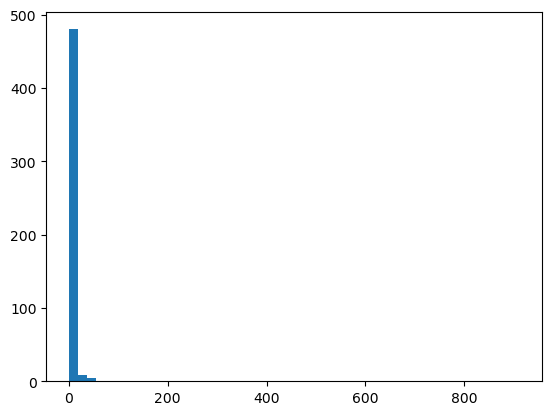

In [1032]:
# plot the distribution of weights
plt.hist(weights_sorted, bins=50)

(array([0.00060993, 0.00365957, 0.00182978, 0.00487942, 0.00548935,
        0.01158862, 0.01463826, 0.02134747, 0.02256731, 0.02744674,
        0.0286666 , 0.02988645, 0.03049637, 0.0243971 , 0.0243971 ,
        0.01951768, 0.01524819, 0.00975884, 0.00548935, 0.00304964]),
 array([-53.17807388, -49.89899445, -46.61991882, -43.34083939,
        -40.06175995, -36.78268433, -33.50360489, -30.22452736,
        -26.94544983, -23.66637039, -20.38729286, -17.10821533,
        -13.82913685, -10.55005836,  -7.27098036,  -3.99190235,
         -0.71282423,   2.5662539 ,   5.84533215,   9.12440968,
         12.40348816]),
 <BarContainer object of 20 artists>)

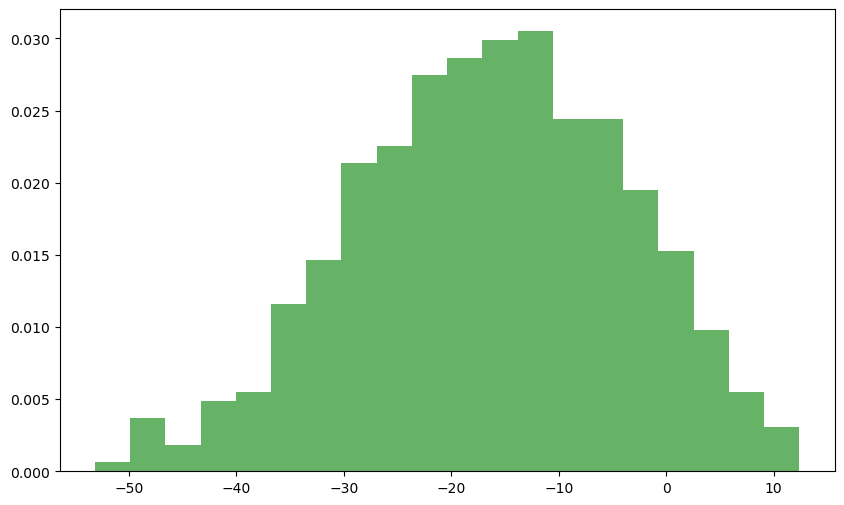

In [1033]:
# plot the distribution of delta_reward
plt.figure(figsize=(10, 6))
plt.hist(delta_reward, bins=20, density=True, alpha=0.6, color='g')

In [1034]:
#calculate w(x,y) using calibration dataset

pi_b_diff = pickle.load(open("saved_trajectories/cal_0_diff.pkl", "rb"))
pi_b_0 = pickle.load(open("saved_trajectories/cal_0_o.pkl", "rb"))

pi_b_diff_trajs = pi_b_diff['trajectories']
pi_b_diff_actions = pi_b_diff['actions']
pi_b_diff_rewards = pi_b_diff['rewards']
pi_b_0_trajs = pi_b_0['trajectories']
pi_b_0_actions = pi_b_0['actions']
pi_b_0_rewards = pi_b_0['rewards']

s0_pairs = []
for i in range(len(pi_b_0_trajs)):
    for j in range(len(pi_b_diff_trajs)):
        if pi_b_0_trajs[i][0] == pi_b_diff_trajs[j][0]:
            s0_pairs.append((i, j))
print(len(s0_pairs))


10000


In [1035]:
def w(x, y):
    matching_pairs = []
    for i1, j1 in s0_pairs:
        if abs(pi_b_0_trajs[i1][0] - x) < eps_s and \
            abs((pi_b_0_rewards[i1] - pi_b_diff_rewards[j1]) - y) < eps_r:
            matching_pairs.append((i1, j1))
    w = 0
    n = len(matching_pairs)
    for i, j in matching_pairs:
        w1 = 1
        for t in range(len(pi_b_0_trajs[i])):
            w1 *= pi_e.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t]) * pi_b.prob(pi_b_diff_trajs[j][t], pi_b_diff_actions[j][t]) / \
                pi_e.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t]) / pi_b.prob(pi_b_diff_trajs[j][t], pi_b_diff_actions[j][t])
            # w1 *= pi_n_10_1.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t]) / \
            #     pi_u_0_10.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t])
        w += w1
    if n > 0:
        return w/n
    else:
        return -1

In [1044]:
start_s = 8
# construct conformal prediction interval with level alpha
alpha = 0.01
# search for valid y from -10 to 10
y_list = np.linspace(-10, 10, 100)
CP_1_y = []
for y in y_list:
    w_ = w(start_s, y)
    if w_ > 0:
        # check whether y is in (alpha/2, 1-alpha/2) quantile of F
        new_weights = np.append(weights_sorted, w_)
        normalized_weights = new_weights / np.sum(new_weights)
        # calculate the quantile of the CDF F = \sum w_i * 1(x \le x_i)
        low_level = 0
        high_level = 0
        low_q = 0
        high_q = 0
        for i in range(len(delta_reward_sorted)):
            low_level += normalized_weights[i]
            if low_level >= alpha/2:
                low_q = delta_reward_sorted[i-1]
                break
        for i in range(len(delta_reward_sorted)):
            high_level += normalized_weights[i]
            if high_level >= 1 - alpha/2:
                high_q = delta_reward_sorted[i-1]
                break
        print("low_q: ", low_q)
        print("high_q: ", high_q)
        break
        # if low_q <= y <= high_q:
        #     CP_1_y.append(y)
        #     print("y: ", y)



low_q:  -40.108715
high_q:  0.13414502


In [1045]:
# generate 500 trajectories from pi_n_10_1, saved as first_term
_trajectories = []
_actions_trajectories = []
_rewards = []
for _ in range(500):
    s = np.array(start_s).reshape(1,)
    reward = 0
    trajectory = []
    action_trajectory = []
    for h in range(env.H):
        a = pi_e.act(s)
        s, a, r, s1, done = noisy_env.step(s, a, h)
        trajectory.append(s)
        action_trajectory.append(a)
        reward += r * (gamma ** h)
        s = s1
    _trajectories.append(trajectory)
    _actions_trajectories.append(action_trajectory)
    _rewards.append(reward)

# convert to dictionary
import pickle
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}

# save as 9_first_term.pkl
with open('saved_trajectories/9_first_term.pkl', 'wb') as f:
    pickle.dump(data, f)

pi_e_diff = pickle.load(open("saved_trajectories/9_first_term.pkl", "rb"))

pi_e_diff_trajs = pi_e_diff['trajectories']
pi_e_diff_actions = pi_e_diff['actions']
pi_e_diff_rewards = pi_e_diff['rewards']

hat_V_pi_e = np.mean(pi_e_diff_rewards)

In [1046]:
# calculate the confidence interval
CP = (np.mean(pi_e_diff_rewards) + low_q, np.mean(pi_e_diff_rewards) + high_q)
print("CP: ", CP)

CP:  (-4.768568448154895, 35.47429163065675)


In [1047]:
# evaluate the policies by MC for 1000 episodes
def evaluate_policy(env, policy, gamma, num_episodes=1000):
    total_reward = 0
    for _ in range(num_episodes):
        s = np.array(start_s).reshape(1,)
        for h in range(env.H):
            a = policy.act(s)
            s, a, r, s1, done = env.step(s, a, h)
            total_reward += r * (gamma ** h)
            s = s1
    return total_reward / num_episodes


evaluate_policy(env, pi_e, gamma=gamma, num_episodes=10000)

26.9233040197981

In [936]:
CP_list = []
values_list = []

In [937]:
for start_s in range(0, 11):
    # construct conformal prediction interval with level alpha
    alpha = 0.01
    # search for valid y from -10 to 10
    y_list = np.linspace(-10, 10, 100)
    CP_1_y = []
    for y in y_list:
        w_ = w(start_s, y)
        if w_ > 0:
            # check whether y is in (alpha/2, 1-alpha/2) quantile of F
            new_weights = np.append(weights_sorted, w_)
            normalized_weights = new_weights / np.sum(new_weights)
            # calculate the quantile of the CDF F = \sum w_i * 1(x \le x_i)
            low_level = 0
            high_level = 0
            low_q = 0
            high_q = 0
            for i in range(len(delta_reward_sorted)):
                low_level += normalized_weights[i]
                if low_level >= alpha/2:
                    low_q = delta_reward_sorted[i-1]
                    break
            for i in range(len(delta_reward_sorted)):
                high_level += normalized_weights[i]
                if high_level >= 1 - alpha/2:
                    high_q = delta_reward_sorted[i-1]
                    break
            print("low_q: ", low_q)
            print("high_q: ", high_q)
            break
        
    # generate 500 trajectories from pi_n_10_1, saved as first_term
    _trajectories = []
    _actions_trajectories = []
    _rewards = []
    for _ in range(500):
        s = np.array(start_s).reshape(1,)
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_n_10_1.act(s)
            s, a, r, s1, done = noisy_env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (0.9 ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)

    # convert to dictionary
    import pickle
    data = {
        'trajectories': np.array(_trajectories),
        'actions': np.array(_actions_trajectories),
        'rewards': np.array(_rewards)
    }

    # save as 9_first_term.pkl
    with open('saved_trajectories/9_first_term.pkl', 'wb') as f:
        pickle.dump(data, f)

    pi_e_diff = pickle.load(open("saved_trajectories/9_first_term.pkl", "rb"))

    pi_e_diff_trajs = pi_e_diff['trajectories']
    pi_e_diff_actions = pi_e_diff['actions']
    pi_e_diff_rewards = pi_e_diff['rewards']

    hat_V_pi_e = np.mean(pi_e_diff_rewards)

    CP = (np.mean(pi_e_diff_rewards) + low_q, np.mean(pi_e_diff_rewards) + high_q)
    print("CP: ", CP)

    # evaluate the policies by MC for 1000 episodes
    def evaluate_policy(env, policy, gamma, num_episodes=1000):
        total_reward = 0
        for _ in range(num_episodes):
            s = np.array(start_s).reshape(1,)
            for h in range(env.H):
                a = policy.act(s)
                s, a, r, s1, done = env.step(s, a, h)
                total_reward += r * (gamma ** h)
                s = s1
        return total_reward / num_episodes


    values = {}
    # policies = [pi_u_0_10, pi_u_0_5, pi_u_3_8, pi_u_0_0, pi_u_6_6,
                # pi_sS_3_10, pi_sS_3_6, pi_sS_7_10, pi_sS_1_5, pi_sS_5_8]
    policies = [pi_n_10_1]
    for policy in policies:
        policy_name = str(policy.__class__.__name__) + '_' + str(policy.mu) + '_' + str(policy.sigma)
        values[policy_name] = evaluate_policy(env, policy, gamma=0.9, num_episodes=10000)
        print(f"Policy: {policy_name}, Value: {values[policy_name]}")
    
    CP_list.append(CP)
    values_list.append(values[policy_name])

low_q:  -27.158
high_q:  1.3986043
CP:  (36.44493393417871, 65.00153915401971)
Policy: normal_policy_5.5_1, Value: 55.03128469808284
low_q:  -27.158
high_q:  1.3986043
CP:  (36.754131006989766, 65.31073622683077)
Policy: normal_policy_5.5_1, Value: 55.15667364162071
low_q:  -27.158
high_q:  1.3986043
CP:  (37.158600214359566, 65.71520543420057)
Policy: normal_policy_5.5_1, Value: 55.17581568814847
low_q:  -27.158
high_q:  1.3986043
CP:  (37.231689722219514, 65.78829494206052)
Policy: normal_policy_5.5_1, Value: 55.39566125079199
low_q:  -27.158
high_q:  1.3986043
CP:  (36.676116213079034, 65.23272143292004)
Policy: normal_policy_5.5_1, Value: 55.41238129700306
low_q:  -23.69566
high_q:  0
CP:  (40.98582414555793, 64.6814837830091)
Policy: normal_policy_5.5_1, Value: 55.61666380686406
low_q:  -27.158
high_q:  1.3986043
CP:  (37.10469276979396, 65.66129798963496)
Policy: normal_policy_5.5_1, Value: 55.29688514662465
low_q:  -27.158
high_q:  1.3986043
CP:  (35.01978110407971, 63.576386323

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_67607/4003381284.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, '$V^{\\pi_e}(s_0)$')

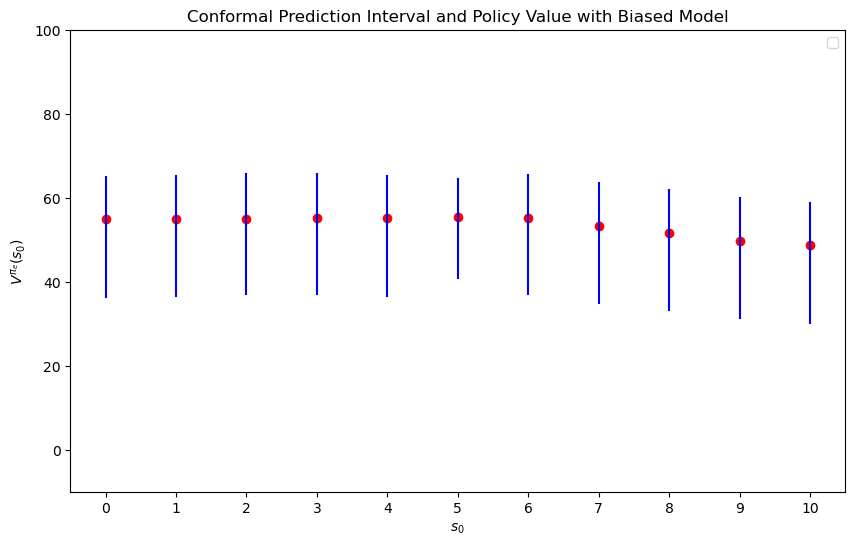

In [938]:
# plot the CP and values
# x-axis: start_s
# y-axis: dot is the value of policy, the interval is the CP
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(range(11), values_list, color='red')
for i in range(len(CP_list)):
    plt.plot([i, i], [CP_list[i][0], CP_list[i][1]], color='blue')
plt.title('Conformal Prediction Interval and Policy Value with Biased Model')
plt.legend()
plt.xticks(range(11))
# y-axis range (0, 100)
plt.ylim(-10, 100)
plt.xlabel('$s_0$')
plt.ylabel('$V^{\pi_e}(s_0)$')


In [897]:
CP_list = []
values_list = []

for start_s in range(0, 11):
    # construct conformal prediction interval with level alpha
    alpha = 0.2
    # search for valid y from -10 to 10
    y_list = np.linspace(-10, 10, 100)
    CP_1_y = []
    for y in y_list:
        w_ = w(start_s, y)
        if w_ > 0:
            # check whether y is in (alpha/2, 1-alpha/2) quantile of F
            new_weights = np.append(weights_sorted, w_)
            normalized_weights = new_weights / np.sum(new_weights)
            # calculate the quantile of the CDF F = \sum w_i * 1(x \le x_i)
            low_level = 0
            high_level = 0
            low_q = 0
            high_q = 0
            for i in range(len(delta_reward_sorted)):
                low_level += normalized_weights[i]
                if low_level >= alpha/2:
                    low_q = delta_reward_sorted[i-1]
                    break
            for i in range(len(delta_reward_sorted)):
                high_level += normalized_weights[i]
                if high_level >= 1 - alpha/2:
                    high_q = delta_reward_sorted[i-1]
                    break
            print("low_q: ", low_q)
            print("high_q: ", high_q)
            break
        
    # generate 500 trajectories from pi_n_10_1, saved as first_term
    _trajectories = []
    _actions_trajectories = []
    _rewards = []
    for _ in range(500):
        s = np.array(start_s).reshape(1,)
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_n_10_1.act(s)
            s, a, r, s1, done = env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (0.9 ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)

    # convert to dictionary
    import pickle
    data = {
        'trajectories': np.array(_trajectories),
        'actions': np.array(_actions_trajectories),
        'rewards': np.array(_rewards)
    }

    # save as 9_first_term.pkl
    with open('saved_trajectories/9_first_term.pkl', 'wb') as f:
        pickle.dump(data, f)

    pi_e_diff = pickle.load(open("saved_trajectories/9_first_term.pkl", "rb"))

    pi_e_diff_trajs = pi_e_diff['trajectories']
    pi_e_diff_actions = pi_e_diff['actions']
    pi_e_diff_rewards = pi_e_diff['rewards']

    hat_V_pi_e = np.mean(pi_e_diff_rewards)

    CP = (np.mean(pi_e_diff_rewards) + low_q, np.mean(pi_e_diff_rewards) + high_q)
    print("CP: ", CP)

    # evaluate the policies by MC for 1000 episodes
    def evaluate_policy(env, policy, gamma, num_episodes=1000):
        total_reward = 0
        for _ in range(num_episodes):
            s = np.array(start_s).reshape(1,)
            for h in range(env.H):
                a = policy.act(s)
                s, a, r, s1, done = env.step(s, a, h)
                total_reward += r * (gamma ** h)
                s = s1
        return total_reward / num_episodes


    values = {}
    # policies = [pi_u_0_10, pi_u_0_5, pi_u_3_8, pi_u_0_0, pi_u_6_6,
                # pi_sS_3_10, pi_sS_3_6, pi_sS_7_10, pi_sS_1_5, pi_sS_5_8]
    policies = [pi_n_10_1]
    for policy in policies:
        policy_name = str(policy.__class__.__name__) + '_' + str(policy.mu) + '_' + str(policy.sigma)
        values[policy_name] = evaluate_policy(env, policy, gamma=0.9, num_episodes=10000)
        print(f"Policy: {policy_name}, Value: {values[policy_name]}")
    
    CP_list.append(CP)
    values_list.append(values[policy_name])

low_q:  -8.106695
high_q:  7.473574
CP:  (47.369689673603325, 62.949959010303765)
Policy: normal_policy_5.5_1, Value: 55.18755592713416
low_q:  -8.106695
high_q:  7.473574
CP:  (47.59108319967403, 63.17135253637447)
Policy: normal_policy_5.5_1, Value: 55.222578684828456
low_q:  -8.106695
high_q:  7.473574
CP:  (46.721522639374456, 62.301791976074895)
Policy: normal_policy_5.5_1, Value: 55.147819198332904
low_q:  -8.106695
high_q:  7.473574
CP:  (47.24277583189748, 62.82304516859792)
Policy: normal_policy_5.5_1, Value: 55.333938456858775
low_q:  -8.106695
high_q:  7.473574
CP:  (47.57476153062232, 63.15503086732276)
Policy: normal_policy_5.5_1, Value: 55.42158916201716
low_q:  -8.106695
high_q:  7.473574
CP:  (47.690738900516806, 63.271008237217245)
Policy: normal_policy_5.5_1, Value: 55.65182137712749
low_q:  -8.106695
high_q:  7.473574
CP:  (47.39073725416909, 62.97100659086953)
Policy: normal_policy_5.5_1, Value: 55.09866321565332
low_q:  -8.106695
high_q:  7.473574
CP:  (45.52670906

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_67607/3851528173.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, '$V^{\\pi_e}(s_0)$')

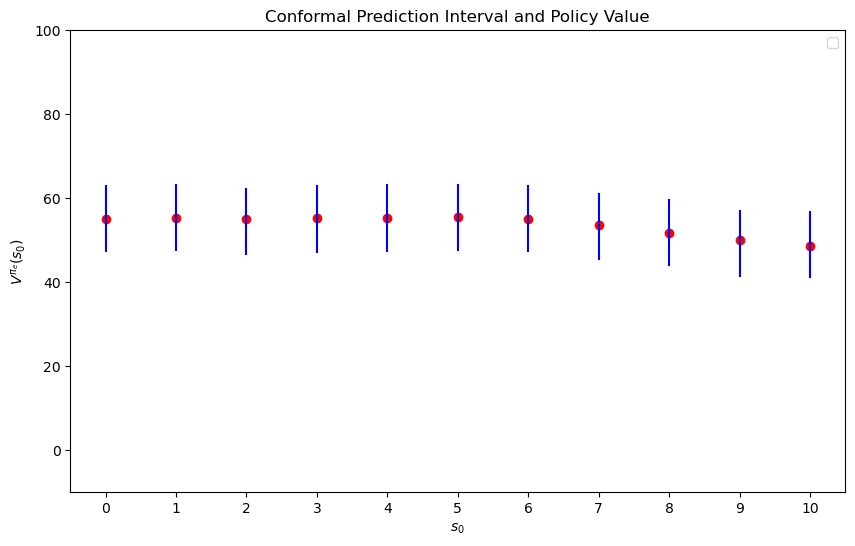

In [898]:
# plot the CP and values
# x-axis: start_s
# y-axis: dot is the value of policy, the interval is the CP
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(range(11), values_list, color='red')
for i in range(len(CP_list)):
    plt.plot([i, i], [CP_list[i][0], CP_list[i][1]], color='blue')
plt.title('Conformal Prediction Interval and Policy Value')
plt.legend()
plt.xticks(range(11))
# y-axis range (0, 100)
plt.ylim(-10, 100)
plt.xlabel('$s_0$')
plt.ylabel('$V^{\pi_e}(s_0)$')
